#  Sprint 2 — EDA: Diagnósticos CIE-10
**Insumo:** `mvnd_limpio.csv`

### Objetivos
- Perfil diagnóstico de las autorizaciones con CIE-10 reportado
- Distribución por capítulo CIE-10
- Relación medicamento ↔ diagnóstico


##  Configuración


In [5]:
%pip install pandas matplotlib seaborn scipy openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys

RUTA_LIMPIO = '../datasets/mvnd_limpio.csv'


plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid', palette='muted')

CARPETA_GRAFICOS = '../graficos/Graficos_eda'
import os
os.makedirs(CARPETA_GRAFICOS, exist_ok=True)

def guardar(fig, nombre):
    ruta = os.path.join(CARPETA_GRAFICOS, nombre)
    fig.savefig(ruta, dpi=150, bbox_inches='tight')
    print(f' Guardado: {ruta}')


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df = pd.read_csv(RUTA_LIMPIO, encoding='utf-8-sig')
df['FECHA_AUTORIZACION'] = pd.to_datetime(df['FECHA_AUTORIZACION'])

# Corregir nombre de columna año parcial (encoding en CSV)
for c in list(df.columns):
    if 'PARCIAL' in c.upper():
        df = df.rename(columns={c: 'ANIO_PARCIAL'})

print(f'Dataset cargado: {len(df):,} registros × {df.shape[1]} columnas')
print(f'Período: {df["FECHA_AUTORIZACION"].min().date()} → {df["FECHA_AUTORIZACION"].max().date()}')


Dataset cargado: 9,413 registros × 21 columnas
Período: 2018-01-09 → 2026-06-12


## 1. Cobertura diagnóstica


 Guardado: ../graficos/Graficos_eda\04_cobertura_diagnostico.png


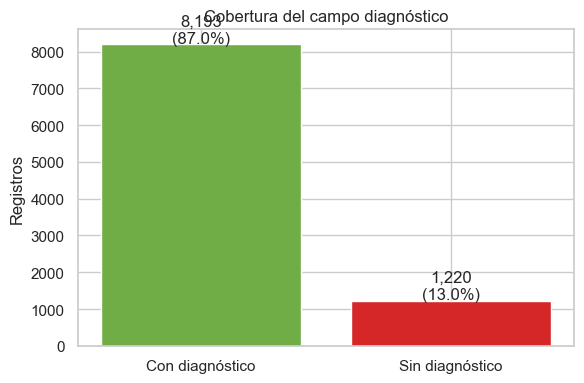

Análisis con diagnóstico: 8,193 registros (87.0%)


In [7]:
import matplotlib.pyplot as plt

# 1. Definimos qué valores significan "Sin diagnóstico" (Nulos o el texto "NO REPORTADO")
# .strip() elimina espacios y .upper() convierte a mayúsculas para evitar fallas por escritura
condicion_sin_dx = df['DIAGNOSTICO'].isna() | (df['DIAGNOSTICO'].astype(str).str.strip().str.upper() == 'NO REPORTADO')

# 2. Calculamos los contadores basados en la condición
sin_dx = condicion_sin_dx.sum()
con_dx = len(df) - sin_dx
pct_sin = sin_dx / len(df) * 100

# 3. Diseño de la gráfica
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Con diagnóstico', 'Sin diagnóstico'], [con_dx, sin_dx], color=['#70AD47', '#d62728'])

for i, v in enumerate([con_dx, sin_dx]):
    ax.text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

ax.set_title('Cobertura del campo diagnóstico')
ax.set_ylabel('Registros')
plt.tight_layout()

# Guardar y mostrar
guardar(plt.gcf(), '04_cobertura_diagnostico.png')
plt.show()

# 4. Filtrado del DataFrame original (Excluimos los nulos y los "NO REPORTADO")
df_dx = df[~condicion_sin_dx].copy()
print(f'Análisis con diagnóstico: {len(df_dx):,} registros ({100-pct_sin:.1f}%)')


## 2. Top diagnósticos textuales


 Guardado: ../graficos/Graficos_eda\04_top15_diagnosticos.png


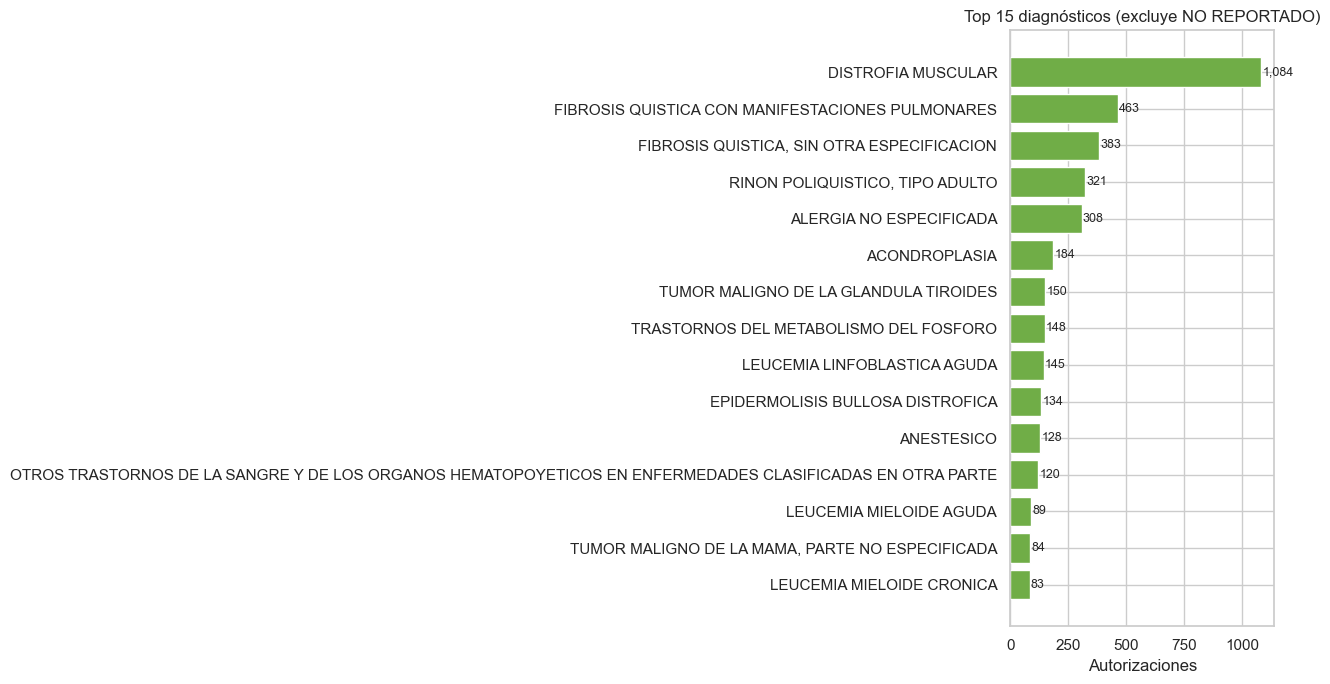

In [8]:

top_dx = df_dx['DIAGNOSTICO'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(top_dx.index[::-1], top_dx.values[::-1], color='#70AD47')
for bar, val in zip(ax.patches, top_dx.values[::-1]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_title('Top 15 diagnósticos (excluye NO REPORTADO)')
ax.set_xlabel('Autorizaciones')
plt.tight_layout()
guardar(plt.gcf(), '04_top15_diagnosticos.png')
plt.show()



## 3. Capítulos CIE-10


 Guardado: ../graficos/Graficos_eda\04_capitulos_cie10.png


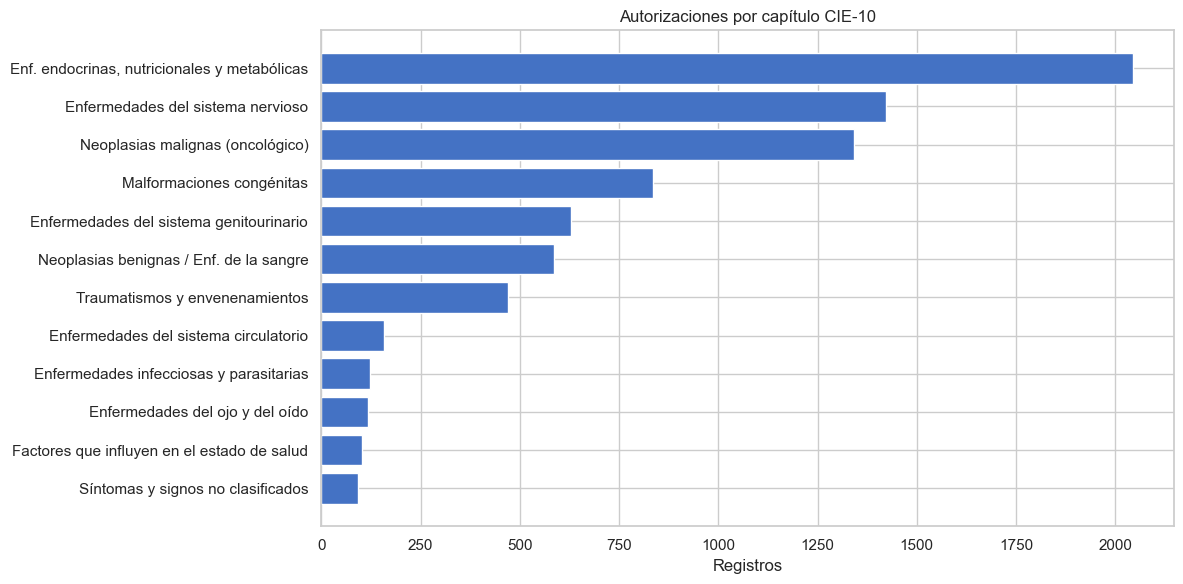

CAPITULO_CIE10
Enf. endocrinas, nutricionales y metabólicas    2046
Enfermedades del sistema nervioso               1422
Neoplasias malignas (oncológico)                1341
Malformaciones congénitas                        836
Enfermedades del sistema genitourinario          629
Neoplasias benignas / Enf. de la sangre          587
Traumatismos y envenenamientos                   471
Enfermedades del sistema circulatorio            157
Enfermedades infecciosas y parasitarias          122
Enfermedades del ojo y del oído                  118
Name: count, dtype: int64


In [9]:

cap = df_dx['CAPITULO_CIE10'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(cap.index[::-1], cap.values[::-1], color='#4472C4')
ax.set_title('Autorizaciones por capítulo CIE-10')
ax.set_xlabel('Registros')
plt.tight_layout()
guardar(plt.gcf(), '04_capitulos_cie10.png')
plt.show()
print(cap.head(10))



## 4. Heatmap: capítulo CIE-10 × tipo de solicitud


 Guardado: ../graficos/Graficos_eda\04_heatmap_capitulo_tipo.png


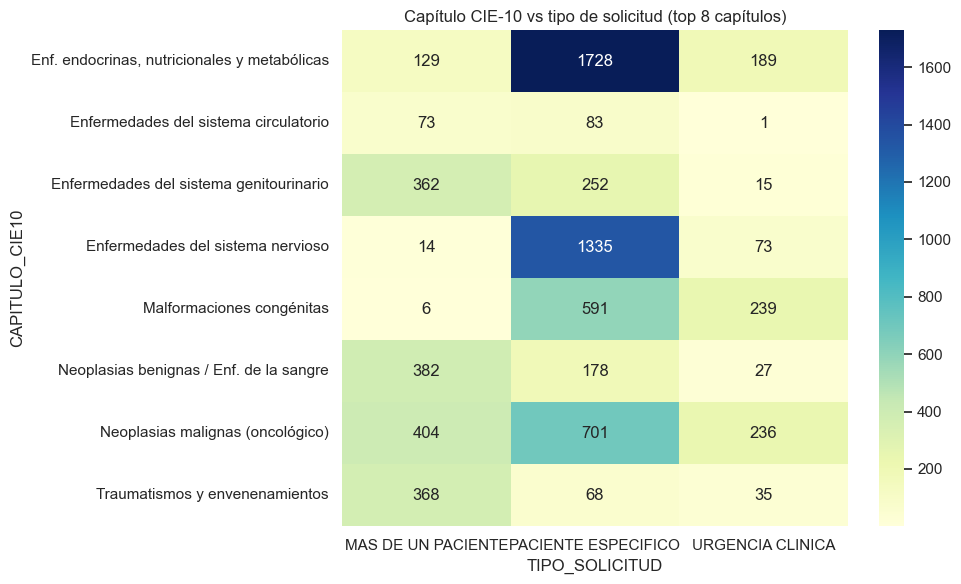

In [10]:

top_cap = df_dx['CAPITULO_CIE10'].value_counts().head(8).index
tab = pd.crosstab(df_dx[df_dx['CAPITULO_CIE10'].isin(top_cap)]['CAPITULO_CIE10'],
                  df_dx[df_dx['CAPITULO_CIE10'].isin(top_cap)]['TIPO_SOLICITUD'])
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(tab, annot=True, fmt='d', cmap='YlGnBu', ax=ax)
ax.set_title('Capítulo CIE-10 vs tipo de solicitud (top 8 capítulos)')
plt.tight_layout()
guardar(plt.gcf(), '04_heatmap_capitulo_tipo.png')
plt.show()



## 5. Principio activo vs capítulo (top medicamentos)


 Guardado: ../graficos/Graficos_eda\04_heatmap_medicamento_capitulo.png


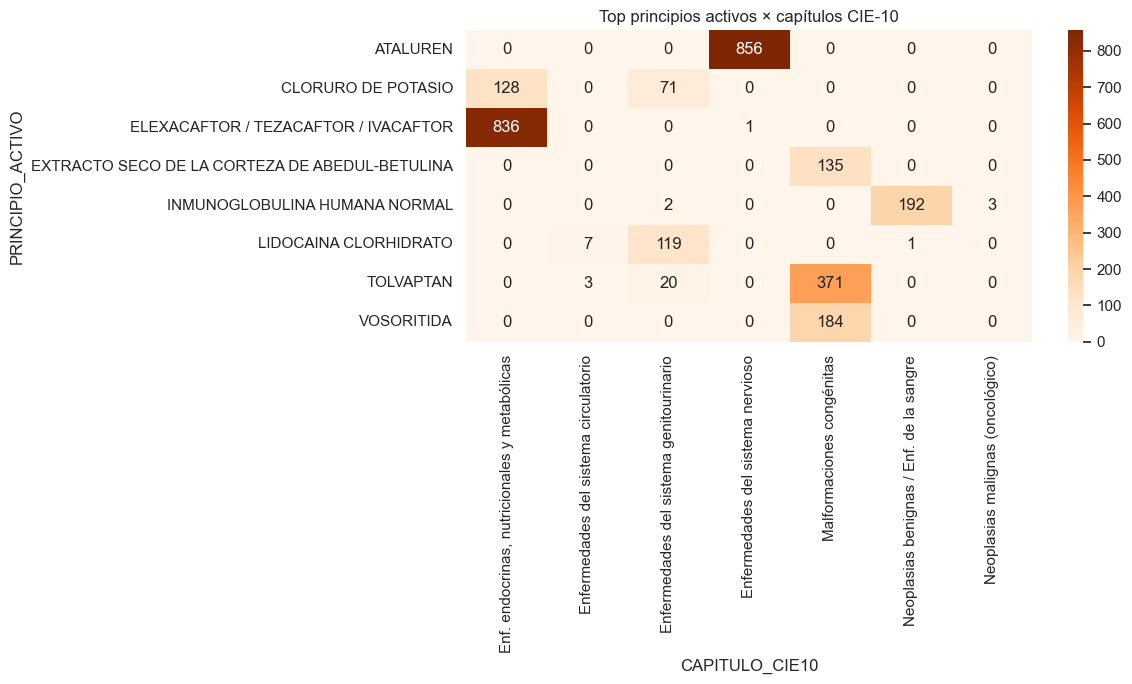

In [11]:

top_pa = df_dx['PRINCIPIO_ACTIVO'].value_counts().head(8).index
top_c = df_dx['CAPITULO_CIE10'].value_counts().head(8).index
sub = df_dx[df_dx['PRINCIPIO_ACTIVO'].isin(top_pa) & df_dx['CAPITULO_CIE10'].isin(top_c)]
tab2 = pd.crosstab(sub['PRINCIPIO_ACTIVO'], sub['CAPITULO_CIE10'])
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(tab2, annot=True, fmt='d', cmap='Oranges', ax=ax)
ax.set_title('Top principios activos × capítulos CIE-10')
plt.tight_layout()
guardar(plt.gcf(), '04_heatmap_medicamento_capitulo.png')
plt.show()



## Hallazgos — Sprint 2 (Diagnósticos)

| Hallazgo | Evidencia |
|----------|-----------|
| Datos faltantes | ~13,4% sin diagnóstico — limitar inferencias al subconjunto con CIE-10 |
| Oncología y endocrino | Capítulos C y E concentran gran parte de la demanda con diagnóstico |
| Coherencia clínica | ELEXACAFTOR/TEZACAFTOR/IVACAFTOR se asocia a capítulo respiratorio/endocrino (fibrosis quística) |
| Urgencias | Distribución heterogénea por capítulo en `URGENCIA CLINICA` |

**Siguiente:** `05_EDA_Importadores.ipynb`
